<a href="https://colab.research.google.com/github/alwinjackoaids24-dev/-task-manager-app/blob/main/Task2/CodeAlpha_Task2_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

print("Step 1 Done: Libraries ready ✅")

Step 1 Done: Libraries ready ✅


In [2]:
# Titanic dataset load panrom
df = sns.load_dataset('titanic')

# First 5 rows paakalam
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
print("Dataset Shape:", df.shape)  # (891, 15) nu varum
print("\nColumn Names:")
print(df.columns.tolist())
print("\nInfo:")
df.info()

Dataset Shape: (891, 15)

Column Names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone    

Missing Values Count:
deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64


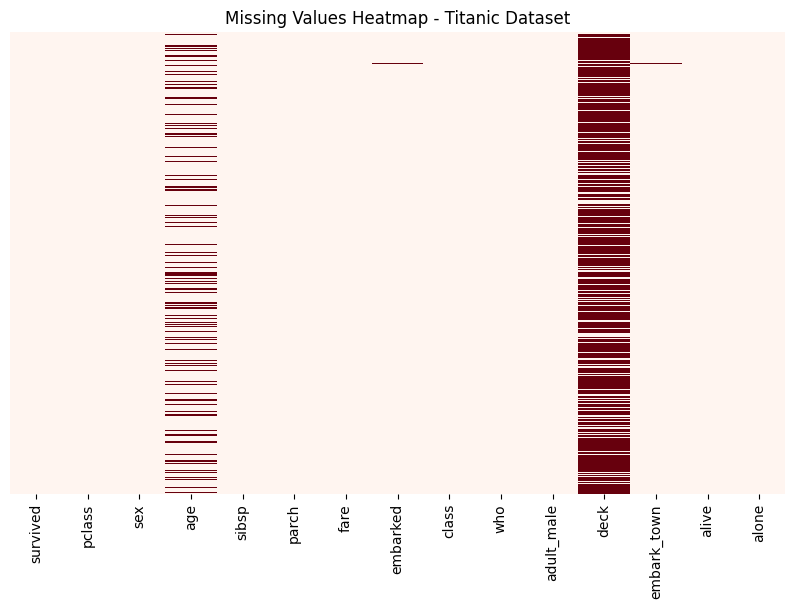

In [4]:
print("Missing Values Count:")
print(df.isnull().sum().sort_values(ascending=False))

# Heatmap - enga lam missing iruku nu visual ah paakalam
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='Reds', yticklabels=False)
plt.title('Missing Values Heatmap - Titanic Dataset')
plt.show()

In [5]:
# Numerical columns ku stats
df.describe()

# Categorical vs Numerical separate pannu
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical Columns: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


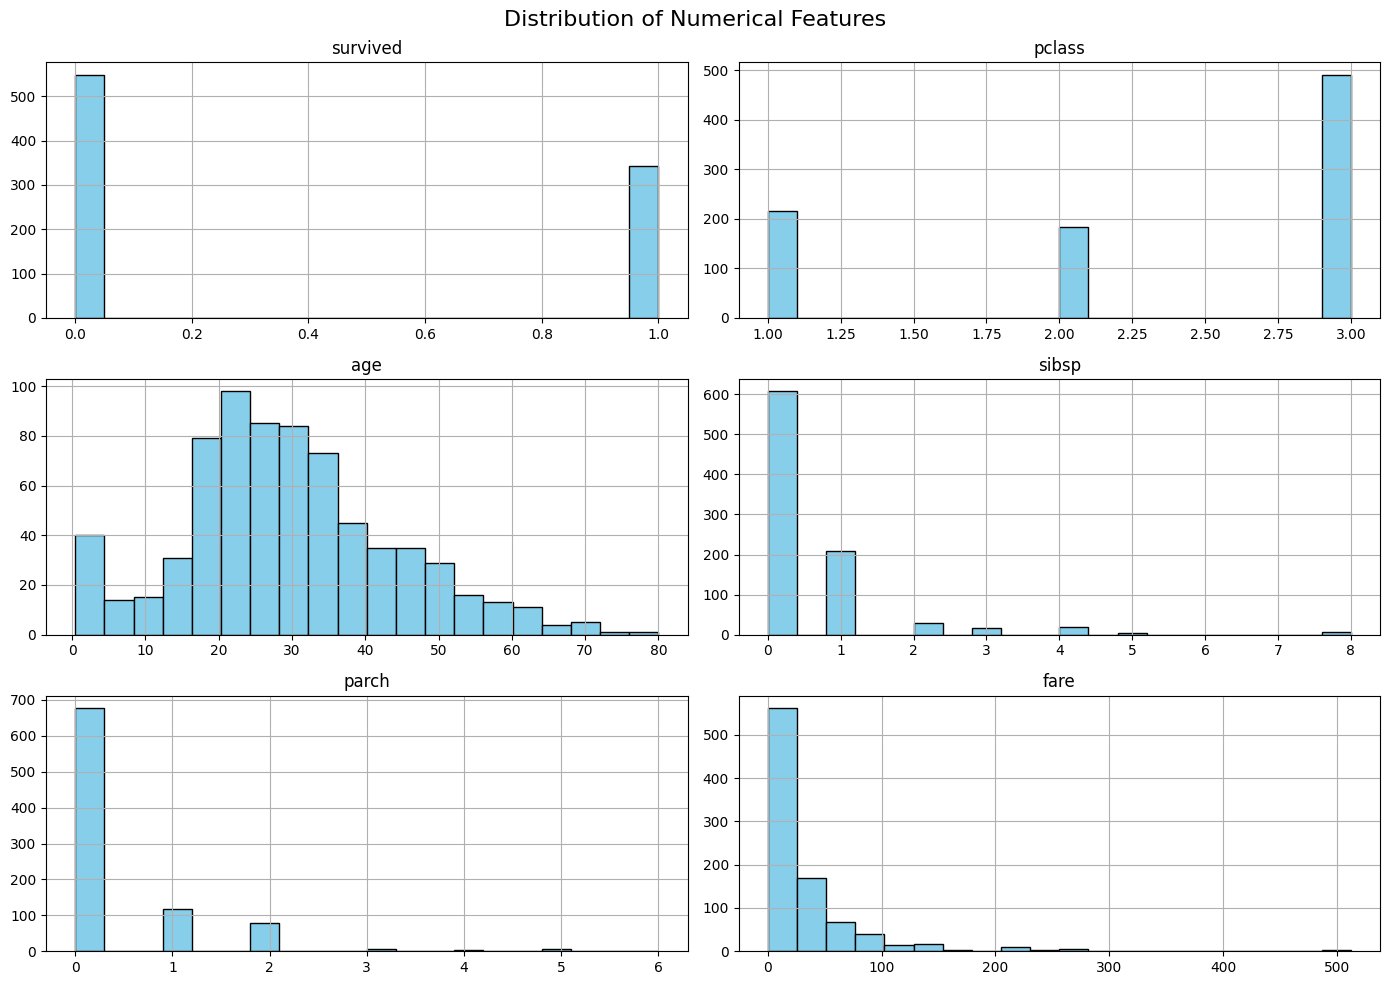

In [6]:
df[num_cols].hist(figsize=(14,10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

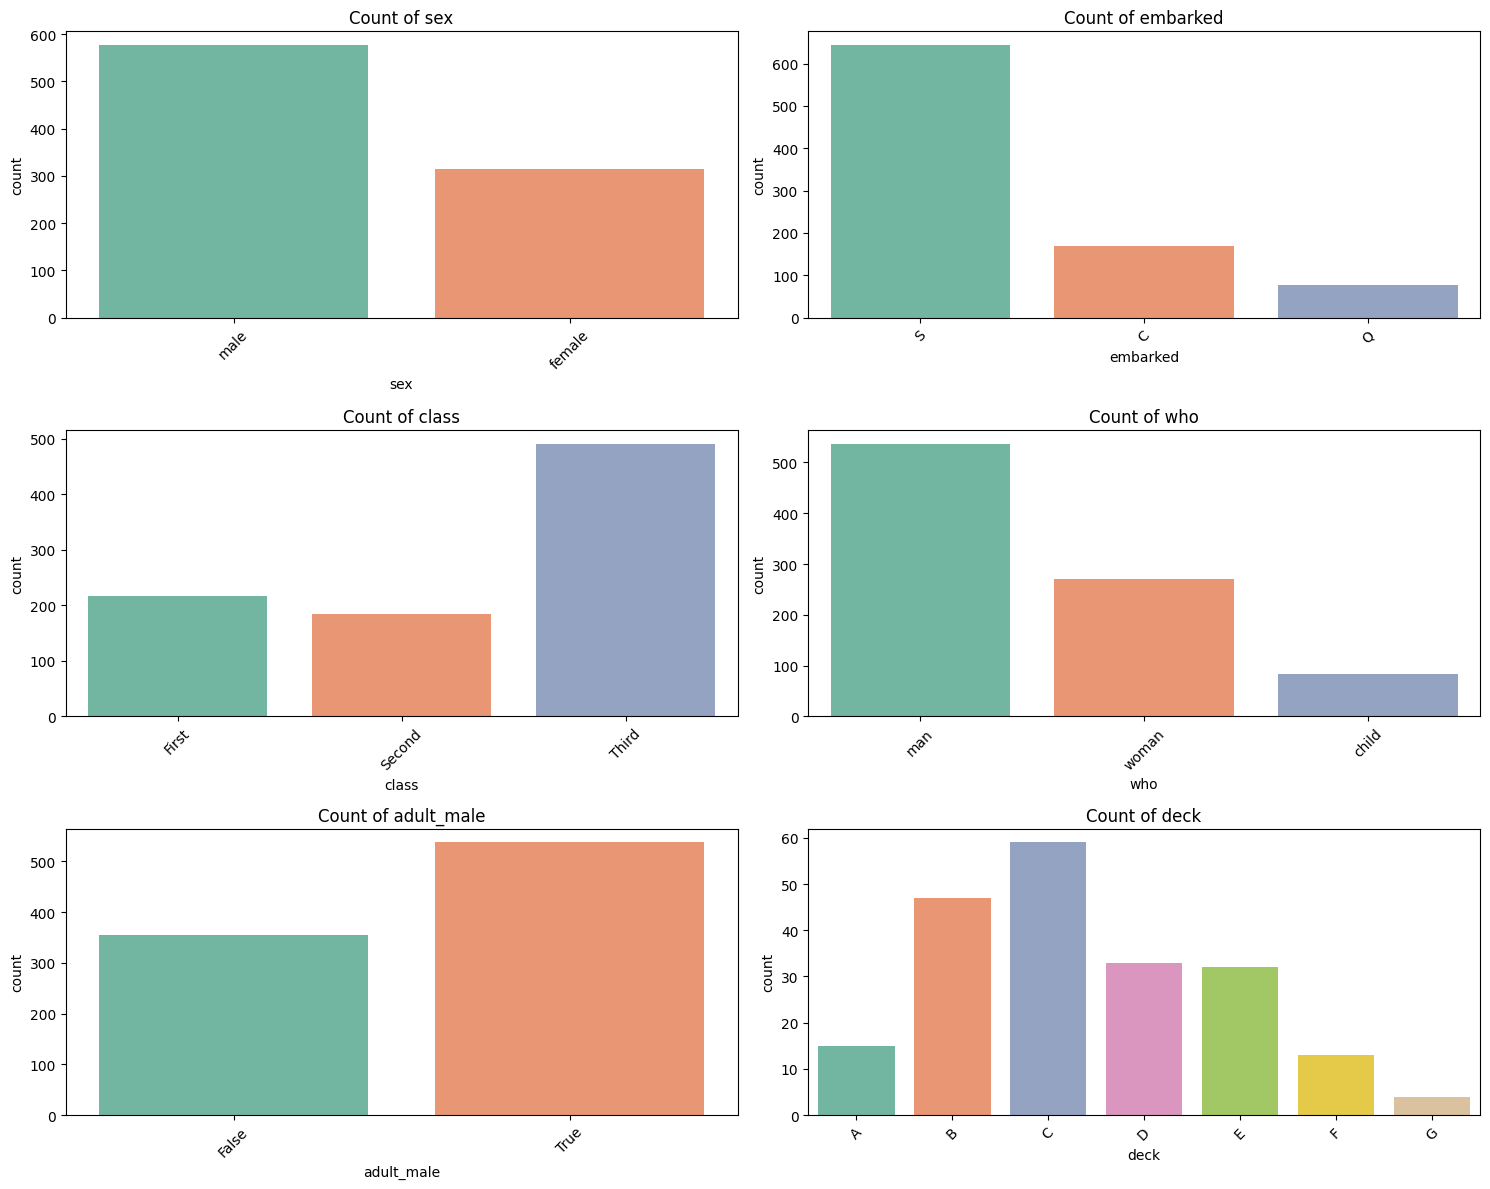

In [7]:
plt.figure(figsize=(15,12))
for i, col in enumerate(cat_cols[:6]):
    plt.subplot(3, 2, i+1)
    sns.countplot(x=col, data=df, palette='Set2', hue=col, legend=False)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

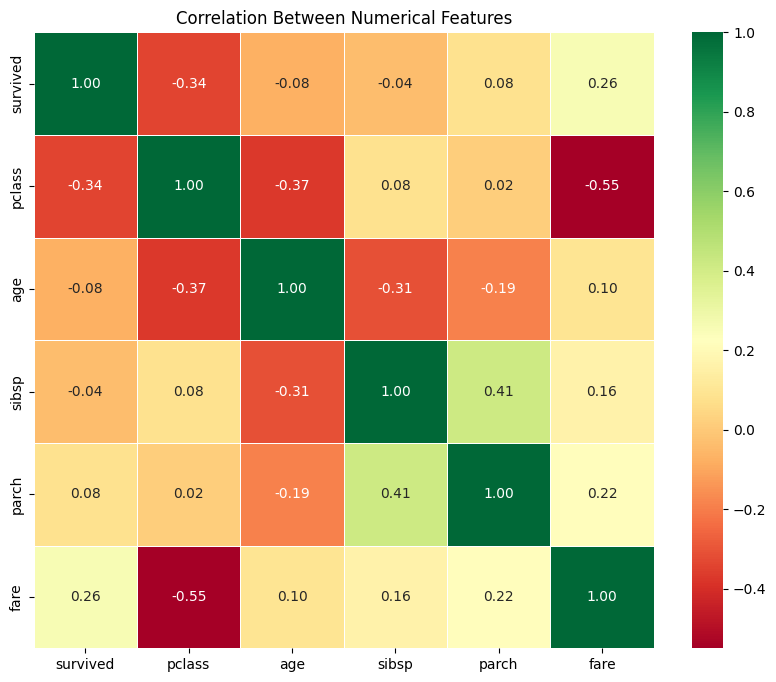

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Correlation Between Numerical Features')
plt.show()

/tmp/ipykernel_5817/1425057777.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex', y='survived', data=df, ax=axes[0], palette='pastel', errorbar=None)
/tmp/ipykernel_5817/1425057777.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='pclass', y='survived', data=df, ax=axes[1], palette='pastel', errorbar=None)
/tmp/ipykernel_5817/1425057777.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='survived', y='age', data=df, ax=axes[2], palette='pastel')


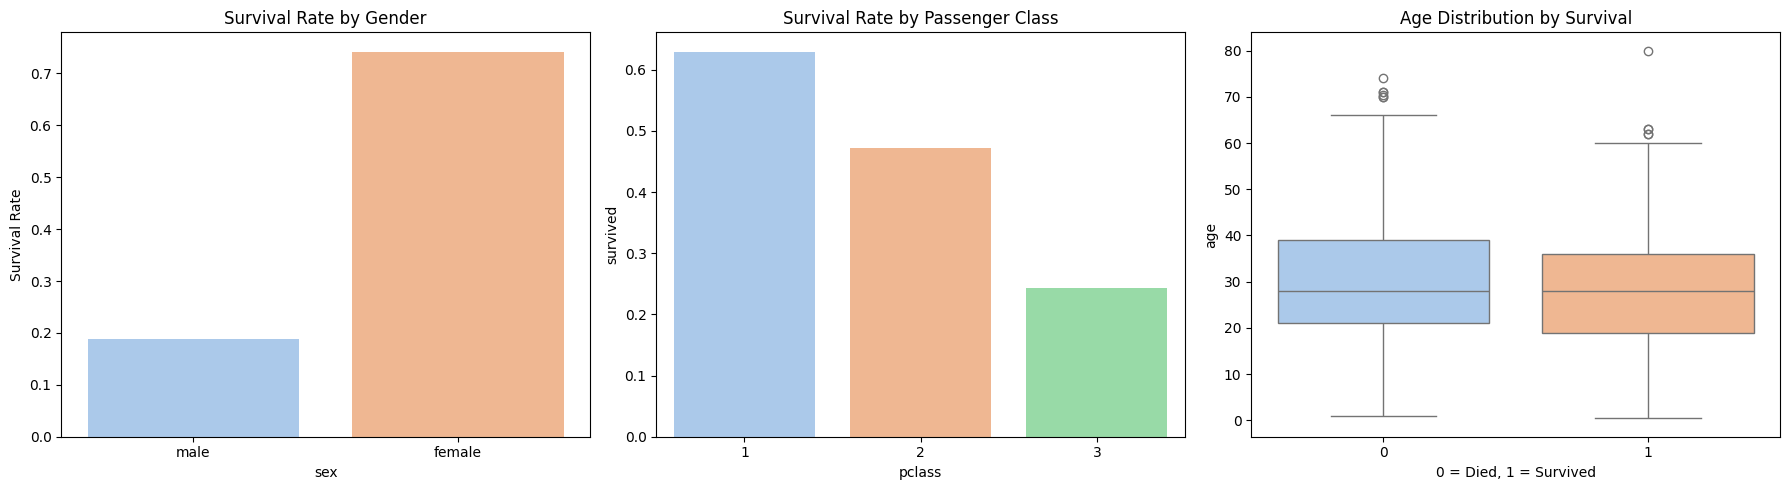

Survival Rate by Gender:
sex
female    74.203822
male      18.890815
Name: survived, dtype: float64

Survival Rate by Class:
pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 1. Gender vs Survival - "Women and children first" rule proof
sns.barplot(x='sex', y='survived', data=df, ax=axes[0], palette='pastel', errorbar=None)
axes[0].set_title('Survival Rate by Gender')
axes[0].set_ylabel('Survival Rate')

# 2. Class vs Survival - Panam irundha uyir thapichidum
sns.barplot(x='pclass', y='survived', data=df, ax=axes[1], palette='pastel', errorbar=None)
axes[1].set_title('Survival Rate by Passenger Class')

# 3. Age vs Survival - Chinna vayasu chance adhigam
sns.boxplot(x='survived', y='age', data=df, ax=axes[2], palette='pastel')
axes[2].set_title('Age Distribution by Survival')
axes[2].set_xlabel('0 = Died, 1 = Survived')

plt.tight_layout()
plt.show()

# Exact numbers venumna:
print("Survival Rate by Gender:")
print(df.groupby('sex')['survived'].mean() * 100)
print("\nSurvival Rate by Class:")
print(df.groupby('pclass')['survived'].mean() * 100)